# Introduction




South Africa has unequal healthcare access. This project analyzes hospital and health data to identify regions with limited access and how the NHI could help

# Project Objectives




Identify regions in South Africa with limited healthcare access.

Analyze disparities using hospital, health indicator, and life expectancy data.

Show how the NHI could improve healthcare equity.

# Importing neccessary libraries


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
from prophet import Prophet

# Loading all the datasets

In [83]:
life_expectancy = pd.read_csv('/content/drive/MyDrive/october/Life_Expectancy_Data.csv')
facilities = pd.read_csv('/content/drive/MyDrive/october/cfa-data-hospitals-in-africa-00-ssa-mfl-130219.xlsx-ssa-mfl (1).csv')
health = pd.read_csv('/content/drive/MyDrive/october/health_zaf.csv')

# Cleaning the facilities dataset

Checking the first 10 rows

In [84]:
facilities.head(10)

,Country,Facility name,Facility type,Ownership,Lat,Long,LL source
0,Angola,Hospital Barra Do Dande,Hospital,Govt.,-8.6560,13.4919,Google Earth
1,Angola,Hospital Dos Dembos,Hospital,Govt.,-8.5026,14.5862,Google Earth
2,Angola,Hospital Municipal de Ambriz,Municipal Hospital,Govt.,-7.8522,13.1307,Google Earth
3,Angola,Hospital Municipal de Bula Atumba,Municipal Hospital,Govt.,-8.6742,14.7925,Google Earth
4,Angola,Hospital Municipal de Dande,Municipal Hospital,Govt.,-8.5835,13.6569,Google Earth
5,Angola,Hospital Municipal de Nambuangogo,Municipal Hospital,Govt.,-8.1328,14.2947,Google Earth
6,Angola,Hospital Municipal de Pango Aluquem,Municipal Hospital,Govt.,-8.7131,14.4626,Google Earth
7,Angola,Hospital Municipal de Quibaxe,Municipal Hospital,Govt.,-8.4996,14.5866,Google Earth
8,Angola,Hospital Provincial de Bengo,Provincial Hospital,Govt.,-8.5824,13.6594,Google Earth
9,Angola,27 de Marto Health Post,Posto de Saúde,MoH,NaN,NaN,NaN


Renaming the column names

In [85]:
facilities = facilities.rename(columns={
    'Country': 'country',
    'Facility name': 'facility_name',
    'Facility type': 'facility_type',
    'Ownership': 'ownership',
    'Lat': 'latitude',
    'Long': 'longitude',
    'LL source': 'source'
})

# Check new column names
facilities.columns


Index(['country', 'facility_name', 'facility_type', 'ownership', 'latitude',
       'longitude', 'source'],
      dtype='object')

Checking column names, data types and missing values

In [86]:
facilities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98745 entries, 0 to 98744
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        98745 non-null  object 
 1   facility_name  98745 non-null  object 
 2   facility_type  98745 non-null  object 
 3   ownership      68297 non-null  object 
 4   latitude       96395 non-null  float64
 5   longitude      96395 non-null  float64
 6   source         96395 non-null  object 
dtypes: float64(2), object(5)
memory usage: 5.3+ MB


Keeping only rows where country is South Africa

In [87]:
facilities_sa = facilities[facilities['country'] == 'South Africa']

Checking number of rows after filtering

In [88]:
facilities_sa.shape

(4303, 7)

Checking how many duplicates exist

In [89]:
print(facilities_sa.duplicated().sum())

0


Counting the number of missing values per column

In [90]:
facilities_sa.isnull().sum()

,0
country,0
facility_name,0
facility_type,0
ownership,0
latitude,15
longitude,15
source,15


Selecting relevent columns

In [91]:
facilities_sa = facilities_sa[['facility_name', 'facility_type', 'ownership', 'latitude', 'longitude']]
facilities_sa.head()


,facility_name,facility_type,ownership,latitude,longitude
79476,Aberdeen Hospital,District Hospital,MoH,-32.4862,24.0609
79477,Aberdeen Satellite Clinic,Satellite Clinic,MoH,-32.4750,24.0520
79478,AD Keet Clinic,Clinic,MoH,-34.0602,24.9183
79479,Addo Clinic,Clinic,MoH,-33.5422,25.6908
79480,Addo Enon Satellite Clinic,Satellite Clinic,MoH,-33.3946,25.5463


Adding the country column back

In [92]:
facilities_sa['country'] = 'South Africa'

Re-select the relevant columns

In [93]:
facilities_sa = facilities_sa[['country', 'facility_name', 'facility_type', 'ownership', 'latitude', 'longitude']]

# Preview the updated DataFrame
facilities_sa.head(10)

,country,facility_name,facility_type,ownership,latitude,longitude
79476,South Africa,Aberdeen Hospital,District Hospital,MoH,-32.4862,24.0609
79477,South Africa,Aberdeen Satellite Clinic,Satellite Clinic,MoH,-32.4750,24.0520
79478,South Africa,AD Keet Clinic,Clinic,MoH,-34.0602,24.9183
79479,South Africa,Addo Clinic,Clinic,MoH,-33.5422,25.6908
79480,South Africa,Addo Enon Satellite Clinic,Satellite Clinic,MoH,-33.3946,25.5463
79481,South Africa,Adelaide Clinic,Clinic,MoH,-32.7071,26.2946
79482,South Africa,Adelaide Gateway Clinic,Clinic,MoH,-32.6999,26.2940
79483,South Africa,Adelaide Hospital,District Hospital,MoH,-32.7009,26.2943
79484,South Africa,Aeroville Clinic,Clinic,MoH,-32.7496,25.6035
79485,South Africa,Afsondering Clinic,Clinic,MoH,-30.1798,28.9481


Resetting the index

In [94]:
facilities_sa.reset_index(drop=True, inplace=True)
facilities_sa.head()


,country,facility_name,facility_type,ownership,latitude,longitude
0,South Africa,Aberdeen Hospital,District Hospital,MoH,-32.4862,24.0609
1,South Africa,Aberdeen Satellite Clinic,Satellite Clinic,MoH,-32.4750,24.0520
2,South Africa,AD Keet Clinic,Clinic,MoH,-34.0602,24.9183
3,South Africa,Addo Clinic,Clinic,MoH,-33.5422,25.6908
4,South Africa,Addo Enon Satellite Clinic,Satellite Clinic,MoH,-33.3946,25.5463


Dropping rows where latitude and longitude are missing

In [95]:
facilities_sa = facilities_sa.dropna(subset=['latitude', 'longitude']).copy()

Checking if there are still missing values

In [96]:
facilities_sa.isnull().sum()

,0
country,0
facility_name,0
facility_type,0
ownership,0
latitude,0
longitude,0


Checking the first 10 row

In [97]:
facilities_sa.head(10)

,country,facility_name,facility_type,ownership,latitude,longitude
0,South Africa,Aberdeen Hospital,District Hospital,MoH,-32.4862,24.0609
1,South Africa,Aberdeen Satellite Clinic,Satellite Clinic,MoH,-32.4750,24.0520
2,South Africa,AD Keet Clinic,Clinic,MoH,-34.0602,24.9183
3,South Africa,Addo Clinic,Clinic,MoH,-33.5422,25.6908
4,South Africa,Addo Enon Satellite Clinic,Satellite Clinic,MoH,-33.3946,25.5463
5,South Africa,Adelaide Clinic,Clinic,MoH,-32.7071,26.2946
6,South Africa,Adelaide Gateway Clinic,Clinic,MoH,-32.6999,26.2940
7,South Africa,Adelaide Hospital,District Hospital,MoH,-32.7009,26.2943
8,South Africa,Aeroville Clinic,Clinic,MoH,-32.7496,25.6035
9,South Africa,Afsondering Clinic,Clinic,MoH,-30.1798,28.9481


Checking the last 10 rows

In [98]:
facilities_sa.tail(10)

,country,facility_name,facility_type,ownership,latitude,longitude
4292,South Africa,Worcester Gateway Clinic,Clinic,MoH,-33.6457,19.4583
4293,South Africa,Worcester Hospital,Regional Hospital,MoH,-33.6444,19.4581
4294,South Africa,Wupperthal Clinic,Clinic,MoH,-32.2744,19.2186
4295,South Africa,Wynberg Clinic,Clinic,Local authority,-34.0046,18.4701
4296,South Africa,Yzerfontein Satellite Clinic,Satellite Clinic,MoH,-33.3406,18.1638
4297,South Africa,Zakhele Clinic,Clinic,Local authority,-34.0413,18.6593
4298,South Africa,Zoar Clinic,Clinic,MoH,-33.4866,21.4650
4299,South Africa,Zolani Clinic,Clinic,MoH,-33.8375,20.0863
4300,South Africa,Zweletemba Clinic,Clinic,Local authority,-33.6450,19.4437
4301,South Africa,Zwelihle Clinic,Clinic,MoH,-34.4308,19.2133


# Cleaning the life expectancy dataset

Checking the first 10 rows

In [99]:
life_expectancy.head(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263,62,0.01,71.279624,65,1154,...,6,8.16,65,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271,64,0.01,73.523582,62,492,...,58,8.18,62,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268,66,0.01,73.219243,64,430,...,62,8.13,64,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272,69,0.01,78.184215,67,2787,...,67,8.52,67,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275,71,0.01,7.097109,68,3013,...,68,7.87,68,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279,74,0.01,79.679367,66,1989,...,66,9.20,66,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281,77,0.01,56.762217,63,2861,...,63,9.42,63,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287,80,0.03,25.873925,64,1599,...,64,8.33,64,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295,82,0.02,10.910156,63,1141,...,63,6.73,63,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295,84,0.03,17.171518,64,1990,...,58,7.43,58,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


Checking column names, data types and missing values

In [100]:
life_expectancy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1649 entries, 0 to 1648
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          1649 non-null   object 
 1   Year                             1649 non-null   int64  
 2   Status                           1649 non-null   object 
 3   Life expectancy                  1649 non-null   float64
 4   Adult Mortality                  1649 non-null   int64  
 5   infant deaths                    1649 non-null   int64  
 6   Alcohol                          1649 non-null   float64
 7   percentage expenditure           1649 non-null   float64
 8   Hepatitis B                      1649 non-null   int64  
 9   Measles                          1649 non-null   int64  
 10   BMI                             1649 non-null   float64
 11  under-five deaths                1649 non-null   int64  
 12  Polio               

Renaming columns

In [101]:
life_expectancy = life_expectancy.rename(columns={
    'Country': 'country',
    'Year': 'year',
    'Status': 'status',
    'Life expectancy': 'life_expectancy',
    'Adult Mortality': 'adult_mortality',
    'infant deaths': 'infant_deaths',
    'Alcohol': 'alcohol',
    'percentage expenditure': 'percentage_expenditure',
    'Hepatitis B': 'hepatitis_b',
    'Measles': 'measles',
    'BMI': 'bmi',
    'under-five deaths': 'under_five_deaths',
    'Polio': 'polio',
    'Total expenditure': 'total_expenditure',
    'Diphtheria': 'diphtheria',
    ' HIV/AIDS': 'hiv_aids',
    'GDP': 'gdp',
    'Population': 'population',
    ' thinness  1-19 years': 'thinness_1_19',
    ' thinness 5-9 years': 'thinness_5_9',
    'Income composition of resources': 'income_composition',
    'Schooling': 'schooling'
})


Keeping rows where country is south africa

In [102]:
life_sa = life_expectancy[life_expectancy['country'] == 'South Africa'].copy()

Checking the first 10 rows

In [103]:
life_sa.head(10)

,country,year,status,Life expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,Measles,...,polio,total_expenditure,Diphtheria,hiv_aids,gdp,population,thinness_1_19,thinness_5_9,income_composition,schooling
1361,South Africa,2014,Developing,62.0,347,42,7.38,922.050731,8,66,...,77,8.80,77,3.7,6479.625659,54146734.74,4.9,5.9,0.660,13.0
1362,South Africa,2013,Developing,69.0,371,43,7.34,978.590529,7,25,...,73,8.78,73,4.5,6876.953821,53311955.61,5.4,6.5,0.652,12.8
1363,South Africa,2012,Developing,59.2,48,43,7.38,1089.954838,68,32,...,65,8.79,65,7.6,7548.163698,5256515.80,6.0,7.3,0.644,12.8
1364,South Africa,2011,Developing,58.9,413,43,7.38,123.753335,76,92,...,69,8.61,69,8.5,849.954224,51729345.36,6.6,8.0,0.638,12.8
1365,South Africa,2010,Developing,58.0,428,43,7.28,1038.885632,71,12499,...,72,8.50,72,11.0,7362.761390,5979432.36,7.3,8.9,0.630,12.8
1366,South Africa,2009,Developing,56.5,449,46,7.60,782.598714,74,5857,...,75,8.39,76,19.0,5888.628400,5255813.11,8.1,9.8,0.622,12.8
1367,South Africa,2008,Developing,55.3,473,50,8.19,780.033642,76,39,...,77,7.75,79,23.5,5786.599720,49557573.30,8.9,1.7,0.616,12.9
1368,South Africa,2007,Developing,54.5,486,51,8.48,805.490079,83,31,...,79,7.53,82,26.4,6125.399840,48883844.99,9.7,11.7,0.612,12.9
1369,South Africa,2006,Developing,54.0,496,54,8.50,732.125530,83,81,...,79,7.57,82,28.1,5631.734850,4823384.48,1.6,12.8,0.609,12.9
1370,South Africa,2005,Developing,53.8,498,55,8.69,709.317097,79,615,...,75,7.77,79,29.5,5414.634326,476667.24,11.6,13.9,0.609,12.9


Removing extra spaces from column names

In [104]:
life_sa.columns = life_sa.columns.str.strip()

Renaming columns names that we not renamed because of the spaces

In [105]:
life_sa = life_sa.rename(columns={
    'Life expectancy': 'life_expectancy',
    ' BMI': 'bmi'
})

Checking duplicates

In [106]:
duplicates_count = life_sa.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

Number of duplicate rows: 0


Resetting index

In [107]:
life_sa.reset_index(drop=True, inplace=True)

Quick check

In [108]:
life_sa.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,Measles,...,polio,total_expenditure,Diphtheria,hiv_aids,gdp,population,thinness_1_19,thinness_5_9,income_composition,schooling
0,South Africa,2014,Developing,62.0,347,42,7.38,922.050731,8,66,...,77,8.80,77,3.7,6479.625659,54146734.74,4.9,5.9,0.660,13.0
1,South Africa,2013,Developing,69.0,371,43,7.34,978.590529,7,25,...,73,8.78,73,4.5,6876.953821,53311955.61,5.4,6.5,0.652,12.8
2,South Africa,2012,Developing,59.2,48,43,7.38,1089.954838,68,32,...,65,8.79,65,7.6,7548.163698,5256515.80,6.0,7.3,0.644,12.8
3,South Africa,2011,Developing,58.9,413,43,7.38,123.753335,76,92,...,69,8.61,69,8.5,849.954224,51729345.36,6.6,8.0,0.638,12.8
4,South Africa,2010,Developing,58.0,428,43,7.28,1038.885632,71,12499,...,72,8.50,72,11.0,7362.761390,5979432.36,7.3,8.9,0.630,12.8


Keeping columns I think they are relevant

In [109]:
life_sa.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 15 non-null     object 
 1   year                    15 non-null     int64  
 2   status                  15 non-null     object 
 3   life_expectancy         15 non-null     float64
 4   adult_mortality         15 non-null     int64  
 5   infant_deaths           15 non-null     int64  
 6   alcohol                 15 non-null     float64
 7   percentage_expenditure  15 non-null     float64
 8   hepatitis_b             15 non-null     int64  
 9   Measles                 15 non-null     int64  
 10  BMI                     15 non-null     float64
 11  under-five deaths       15 non-null     int64  
 12  polio                   15 non-null     int64  
 13  total_expenditure       15 non-null     float64
 14  Diphtheria              15 non-null     int6

 Selecting relevant columns

In [110]:
print(life_sa.columns)
life_sa = life_sa[['country', 'year', 'life_expectancy', 'gdp', 'population']].copy()

Index(['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b',
       'Measles', 'BMI', 'under-five deaths', 'polio', 'total_expenditure',
       'Diphtheria', 'hiv_aids', 'gdp', 'population', 'thinness_1_19',
       'thinness_5_9', 'income_composition', 'schooling'],
      dtype='object')


Check first 10 rows

In [111]:
life_sa.head(10)

,country,year,life_expectancy,gdp,population
0,South Africa,2014,62.0,6479.625659,54146734.74
1,South Africa,2013,69.0,6876.953821,53311955.61
2,South Africa,2012,59.2,7548.163698,5256515.80
3,South Africa,2011,58.9,849.954224,51729345.36
4,South Africa,2010,58.0,7362.761390,5979432.36
5,South Africa,2009,56.5,5888.628400,5255813.11
6,South Africa,2008,55.3,5786.599720,49557573.30
7,South Africa,2007,54.5,6125.399840,48883844.99
8,South Africa,2006,54.0,5631.734850,4823384.48
9,South Africa,2005,53.8,5414.634326,476667.24


# Cleaning the health indicator

Checking the first 10 rows

In [112]:
health.head(10)

,Country Name,Country ISO3,Year,Indicator Name,Indicator Code,Value
0,#country+name,#country+code,#date+year,#indicator+name,#indicator+code,#indicator+value+num
1,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.ARGU.ZS,2.2
2,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.BURN.ZS,1
3,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.GOES.ZS,2.1
4,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.NEGL.ZS,3.8
5,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.REAS.ZS,5.5
6,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.REFU.ZS,1
7,South Africa,ZAF,2020,"Total alcohol consumption per capita, female (...",SH.ALC.PCAP.FE.LI,2.31
8,South Africa,ZAF,2019,"Total alcohol consumption per capita, female (...",SH.ALC.PCAP.FE.LI,2.93
9,South Africa,ZAF,2018,"Total alcohol consumption per capita, female (...",SH.ALC.PCAP.FE.LI,2.93


removing extra header

In [113]:
health = health.iloc[1:].copy()

Resetting the index

In [114]:
health.reset_index(drop=True, inplace=True)

Quick check

In [115]:
health.head()

,Country Name,Country ISO3,Year,Indicator Name,Indicator Code,Value
0,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.ARGU.ZS,2.2
1,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.BURN.ZS,1
2,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.GOES.ZS,2.1
3,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.NEGL.ZS,3.8
4,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.REAS.ZS,5.5


Checking last 10 rows

In [116]:
health.tail(10)

,Country Name,Country ISO3,Year,Indicator Name,Indicator Code,Value
8550,South Africa,ZAF,2005,Increase in poverty gap at $3.10 ($ 2011 PPP) ...,SH.UHC.NOP2.ZG,0.42523
8551,South Africa,ZAF,2000,Increase in poverty gap at $3.10 ($ 2011 PPP) ...,SH.UHC.NOP2.ZG,0.21538
8552,South Africa,ZAF,2010,Number of people spending more than 10% of hou...,SH.UHC.OOPC.10.TO,717000
8553,South Africa,ZAF,2005,Number of people spending more than 10% of hou...,SH.UHC.OOPC.10.TO,831000
8554,South Africa,ZAF,2000,Number of people spending more than 10% of hou...,SH.UHC.OOPC.10.TO,1810000
8555,South Africa,ZAF,1995,Number of people spending more than 10% of hou...,SH.UHC.OOPC.10.TO,2474000
8556,South Africa,ZAF,2010,Number of people spending more than 25% of hou...,SH.UHC.OOPC.25.TO,63000
8557,South Africa,ZAF,2005,Number of people spending more than 25% of hou...,SH.UHC.OOPC.25.TO,88000
8558,South Africa,ZAF,2000,Number of people spending more than 25% of hou...,SH.UHC.OOPC.25.TO,155000
8559,South Africa,ZAF,1995,Number of people spending more than 25% of hou...,SH.UHC.OOPC.25.TO,624000


Checking basics information

In [117]:
health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8560 entries, 0 to 8559
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Country Name    8560 non-null   object
 1   Country ISO3    8560 non-null   object
 2   Year            8560 non-null   object
 3   Indicator Name  8560 non-null   object
 4   Indicator Code  8560 non-null   object
 5   Value           8560 non-null   object
dtypes: object(6)
memory usage: 401.4+ KB


Filter for South Africa

In [118]:
health_sa = health[health['Country Name'] == 'South Africa'].copy()

Reset index

In [119]:
health_sa.reset_index(drop=True, inplace=True)

Quick check

In [120]:
health_sa.head(10)

,Country Name,Country ISO3,Year,Indicator Name,Indicator Code,Value
0,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.ARGU.ZS,2.2
1,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.BURN.ZS,1
2,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.GOES.ZS,2.1
3,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.NEGL.ZS,3.8
4,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.REAS.ZS,5.5
5,South Africa,ZAF,2016,Women who believe a husband is justified in be...,SG.VAW.REFU.ZS,1
6,South Africa,ZAF,2020,"Total alcohol consumption per capita, female (...",SH.ALC.PCAP.FE.LI,2.31
7,South Africa,ZAF,2019,"Total alcohol consumption per capita, female (...",SH.ALC.PCAP.FE.LI,2.93
8,South Africa,ZAF,2018,"Total alcohol consumption per capita, female (...",SH.ALC.PCAP.FE.LI,2.93
9,South Africa,ZAF,2017,"Total alcohol consumption per capita, female (...",SH.ALC.PCAP.FE.LI,2.92


In [121]:
health_sa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8560 entries, 0 to 8559
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Country Name    8560 non-null   object
 1   Country ISO3    8560 non-null   object
 2   Year            8560 non-null   object
 3   Indicator Name  8560 non-null   object
 4   Indicator Code  8560 non-null   object
 5   Value           8560 non-null   object
dtypes: object(6)
memory usage: 401.4+ KB


In [122]:
health_sa.rename(columns={
    'Country Name': 'country',
    'Country ISO3': 'iso3',
    'Year': 'year',
    'Indicator Name': 'indicator',
    'Indicator Code': 'code',
    'Value': 'value'
}, inplace=True)


Convert year to integer

In [123]:
health_sa['Year'] = health_sa['year'].astype(int)

Convert value to numeric float, forcing errors to NaN

In [124]:
health_sa['Value'] = pd.to_numeric(health_sa['value'], errors='coerce')

Checking info to confirm changes

In [125]:
health_sa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8560 entries, 0 to 8559
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    8560 non-null   object 
 1   iso3       8560 non-null   object 
 2   year       8560 non-null   object 
 3   indicator  8560 non-null   object 
 4   code       8560 non-null   object 
 5   value      8560 non-null   object 
 6   Year       8560 non-null   int64  
 7   Value      8560 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 535.1+ KB


List of indicators relevant

In [126]:
relevant_indicators = [
    'Hospital beds (per 1,000 people)',
    'Physicians (per 1,000 people)',
    'Nurses and midwives (per 1,000 people)',
    'Life expectancy at birth, total (years)'
]




Filter dataset

In [127]:
health_sa = health_sa[health_sa['indicator'].isin(relevant_indicators)].copy()

In [128]:
health_sa.reset_index(drop=True, inplace=True)

In [129]:
health_sa.head(10)


,country,iso3,year,indicator,code,value,Year,Value
0,South Africa,ZAF,2010,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,2.28,2010,2.280
1,South Africa,ZAF,2008,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,2.35,2008,2.350
2,South Africa,ZAF,2007,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,2.36,2007,2.360
3,South Africa,ZAF,2005,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,2.8,2005,2.800
4,South Africa,ZAF,2004,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,2.8,2004,2.800
5,South Africa,ZAF,2002,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,3.02,2002,3.020
6,South Africa,ZAF,2020,"Nurses and midwives (per 1,000 people)",SH.MED.NUMW.P3,1.038,2020,1.038
7,South Africa,ZAF,2019,"Nurses and midwives (per 1,000 people)",SH.MED.NUMW.P3,1.113,2019,1.113
8,South Africa,ZAF,2018,"Nurses and midwives (per 1,000 people)",SH.MED.NUMW.P3,1.23,2018,1.230
9,South Africa,ZAF,2012,"Nurses and midwives (per 1,000 people)",SH.MED.NUMW.P3,1.105,2012,1.105


#  Merging datasets

 Merging life expectancy and health indicators datasets

In [130]:
life_sa["year"] = life_sa["year"].astype(int)
health_sa["year"] = health_sa["year"].astype(int)
merged_life_health = pd.merge(
    life_sa,
    health_sa,
    on=["country", "year"],
    how="left"
)

# Preview the result
merged_life_health.head(10)


,country,year,life_expectancy,gdp,population,iso3,indicator,code,value,Year,Value
0,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184
1,South Africa,2013,69.0,6876.953821,53311955.61,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,62.388,2013,62.388
2,South Africa,2012,59.2,7548.163698,5256515.80,ZAF,"Nurses and midwives (per 1,000 people)",SH.MED.NUMW.P3,1.105,2012,1.105
3,South Africa,2012,59.2,7548.163698,5256515.80,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,61.737,2012,61.737
4,South Africa,2011,58.9,849.954224,51729345.36,ZAF,"Nurses and midwives (per 1,000 people)",SH.MED.NUMW.P3,1.057,2011,1.057
5,South Africa,2011,58.9,849.954224,51729345.36,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,60.602,2011,60.602
6,South Africa,2010,58.0,7362.761390,5979432.36,ZAF,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,2.28,2010,2.280
7,South Africa,2010,58.0,7362.761390,5979432.36,ZAF,"Nurses and midwives (per 1,000 people)",SH.MED.NUMW.P3,1.011,2010,1.011
8,South Africa,2010,58.0,7362.761390,5979432.36,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,58.886,2010,58.886
9,South Africa,2009,56.5,5888.628400,5255813.11,ZAF,"Nurses and midwives (per 1,000 people)",SH.MED.NUMW.P3,0.94,2009,0.940


In [131]:
final_merged = pd.merge(
    merged_life_health,
    facilities_sa,
    on="country",
    how="left"
)

# Preview the final merged dataset
final_merged.head(10)


,country,year,life_expectancy,gdp,population,iso3,indicator,code,value,Year,Value,facility_name,facility_type,ownership,latitude,longitude
0,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Aberdeen Hospital,District Hospital,MoH,-32.4862,24.0609
1,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Aberdeen Satellite Clinic,Satellite Clinic,MoH,-32.4750,24.0520
2,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,AD Keet Clinic,Clinic,MoH,-34.0602,24.9183
3,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Addo Clinic,Clinic,MoH,-33.5422,25.6908
4,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Addo Enon Satellite Clinic,Satellite Clinic,MoH,-33.3946,25.5463
5,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Adelaide Clinic,Clinic,MoH,-32.7071,26.2946
6,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Adelaide Gateway Clinic,Clinic,MoH,-32.6999,26.2940
7,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Adelaide Hospital,District Hospital,MoH,-32.7009,26.2943
8,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Aeroville Clinic,Clinic,MoH,-32.7496,25.6035
9,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Afsondering Clinic,Clinic,MoH,-30.1798,28.9481


In [132]:
final_merged.head(10)


,country,year,life_expectancy,gdp,population,iso3,indicator,code,value,Year,Value,facility_name,facility_type,ownership,latitude,longitude
0,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Aberdeen Hospital,District Hospital,MoH,-32.4862,24.0609
1,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Aberdeen Satellite Clinic,Satellite Clinic,MoH,-32.4750,24.0520
2,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,AD Keet Clinic,Clinic,MoH,-34.0602,24.9183
3,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Addo Clinic,Clinic,MoH,-33.5422,25.6908
4,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Addo Enon Satellite Clinic,Satellite Clinic,MoH,-33.3946,25.5463
5,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Adelaide Clinic,Clinic,MoH,-32.7071,26.2946
6,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Adelaide Gateway Clinic,Clinic,MoH,-32.6999,26.2940
7,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Adelaide Hospital,District Hospital,MoH,-32.7009,26.2943
8,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Aeroville Clinic,Clinic,MoH,-32.7496,25.6035
9,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Afsondering Clinic,Clinic,MoH,-30.1798,28.9481


In [133]:
final_merged.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150080 entries, 0 to 150079
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   country          150080 non-null  object 
 1   year             150080 non-null  int64  
 2   life_expectancy  150080 non-null  float64
 3   gdp              150080 non-null  float64
 4   population       150080 non-null  float64
 5   iso3             150080 non-null  object 
 6   indicator        150080 non-null  object 
 7   code             150080 non-null  object 
 8   value            150080 non-null  object 
 9   Year             150080 non-null  int64  
 10  Value            150080 non-null  float64
 11  facility_name    150080 non-null  object 
 12  facility_type    150080 non-null  object 
 13  ownership        150080 non-null  object 
 14  latitude         150080 non-null  float64
 15  longitude        150080 non-null  float64
dtypes: float64(6), int64(2), object(8)
mem

In [134]:
final_merged.isnull().sum()

,0
country,0
year,0
life_expectancy,0
gdp,0
population,0
iso3,0
indicator,0
code,0
value,0
Year,0


In [135]:
final_merged.describe()


,year,life_expectancy,gdp,population,Year,Value,latitude,longitude
count,150080.000000,150080.000000,150080.000000,1.500800e+05,150080.000000,150080.000000,150080.000000,150080.000000
mean,2006.371429,56.202857,4796.010516,2.763208e+07,2006.371429,25.421029,-28.653315,27.424679
std,3.847726,3.025000,2089.186743,2.265239e+07,3.847726,27.868605,3.296596,3.591838
min,2000.000000,53.700000,337.225300,4.717990e+03,2000.000000,0.680000,-34.782800,16.481800
25%,2003.000000,54.000000,2681.781000,4.823384e+06,2003.000000,0.812000,-31.559350,26.311275
50%,2006.000000,55.300000,5414.634326,4.489686e+07,2006.000000,2.800000,-28.531250,28.175800
75%,2010.000000,58.000000,6125.399840,4.888384e+07,2010.000000,55.982000,-25.988650,30.081550
max,2014.000000,69.000000,7548.163698,5.414673e+07,2014.000000,63.184000,-13.100900,32.811600


In [136]:
final_merged['population'].describe()


,population
count,1.500800e+05
mean,2.763208e+07
std,2.265239e+07
min,4.717990e+03
25%,4.823384e+06
50%,4.489686e+07
75%,4.888384e+07
max,5.414673e+07


In [137]:
final_merged.shape  # Number of rows and columns


(150080, 16)

In [138]:
final_merged.duplicated().sum()


np.int64(0)

In [139]:
final_merged.head(10)

,country,year,life_expectancy,gdp,population,iso3,indicator,code,value,Year,Value,facility_name,facility_type,ownership,latitude,longitude
0,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Aberdeen Hospital,District Hospital,MoH,-32.4862,24.0609
1,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Aberdeen Satellite Clinic,Satellite Clinic,MoH,-32.4750,24.0520
2,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,AD Keet Clinic,Clinic,MoH,-34.0602,24.9183
3,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Addo Clinic,Clinic,MoH,-33.5422,25.6908
4,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Addo Enon Satellite Clinic,Satellite Clinic,MoH,-33.3946,25.5463
5,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Adelaide Clinic,Clinic,MoH,-32.7071,26.2946
6,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Adelaide Gateway Clinic,Clinic,MoH,-32.6999,26.2940
7,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Adelaide Hospital,District Hospital,MoH,-32.7009,26.2943
8,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Aeroville Clinic,Clinic,MoH,-32.7496,25.6035
9,South Africa,2014,62.0,6479.625659,54146734.74,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,63.184,2014,63.184,Afsondering Clinic,Clinic,MoH,-30.1798,28.9481


In [140]:

final_merged.tail(10)


,country,year,life_expectancy,gdp,population,iso3,indicator,code,value,Year,Value,facility_name,facility_type,ownership,latitude,longitude
150070,South Africa,2000,57.3,337.2253,44896856.0,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,58.368,2000,58.368,Worcester Gateway Clinic,Clinic,MoH,-33.6457,19.4583
150071,South Africa,2000,57.3,337.2253,44896856.0,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,58.368,2000,58.368,Worcester Hospital,Regional Hospital,MoH,-33.6444,19.4581
150072,South Africa,2000,57.3,337.2253,44896856.0,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,58.368,2000,58.368,Wupperthal Clinic,Clinic,MoH,-32.2744,19.2186
150073,South Africa,2000,57.3,337.2253,44896856.0,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,58.368,2000,58.368,Wynberg Clinic,Clinic,Local authority,-34.0046,18.4701
150074,South Africa,2000,57.3,337.2253,44896856.0,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,58.368,2000,58.368,Yzerfontein Satellite Clinic,Satellite Clinic,MoH,-33.3406,18.1638
150075,South Africa,2000,57.3,337.2253,44896856.0,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,58.368,2000,58.368,Zakhele Clinic,Clinic,Local authority,-34.0413,18.6593
150076,South Africa,2000,57.3,337.2253,44896856.0,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,58.368,2000,58.368,Zoar Clinic,Clinic,MoH,-33.4866,21.4650
150077,South Africa,2000,57.3,337.2253,44896856.0,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,58.368,2000,58.368,Zolani Clinic,Clinic,MoH,-33.8375,20.0863
150078,South Africa,2000,57.3,337.2253,44896856.0,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,58.368,2000,58.368,Zweletemba Clinic,Clinic,Local authority,-33.6450,19.4437
150079,South Africa,2000,57.3,337.2253,44896856.0,ZAF,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,58.368,2000,58.368,Zwelihle Clinic,Clinic,MoH,-34.4308,19.2133


In [141]:
final_merged.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150080 entries, 0 to 150079
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   country          150080 non-null  object 
 1   year             150080 non-null  int64  
 2   life_expectancy  150080 non-null  float64
 3   gdp              150080 non-null  float64
 4   population       150080 non-null  float64
 5   iso3             150080 non-null  object 
 6   indicator        150080 non-null  object 
 7   code             150080 non-null  object 
 8   value            150080 non-null  object 
 9   Year             150080 non-null  int64  
 10  Value            150080 non-null  float64
 11  facility_name    150080 non-null  object 
 12  facility_type    150080 non-null  object 
 13  ownership        150080 non-null  object 
 14  latitude         150080 non-null  float64
 15  longitude        150080 non-null  float64
dtypes: float64(6), int64(2), object(8)
mem

In [142]:
final_merged.duplicated().sum()


np.int64(0)

# Data visualisation

Number of facilities by type

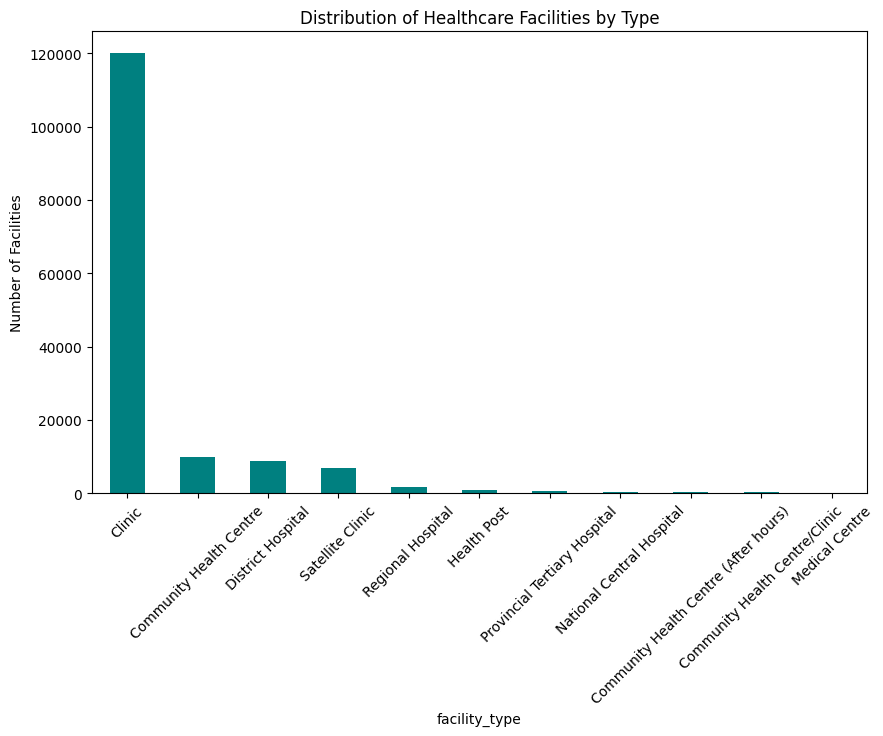

In [143]:
plt.figure(figsize=(10,6))
final_merged['facility_type'].value_counts().plot(kind='bar', color='teal')
plt.title('Distribution of Healthcare Facilities by Type')
plt.ylabel('Number of Facilities')
plt.xticks(rotation=45)
plt.show()


Number of facilities by ownership

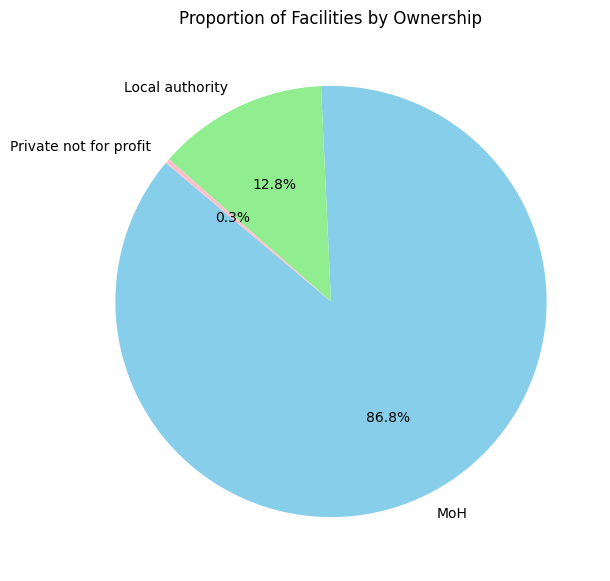

In [144]:
ownership_counts = final_merged['ownership'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(ownership_counts, labels=ownership_counts.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightgreen', 'pink', 'orange'])
plt.title('Proportion of Facilities by Ownership')
plt.show()



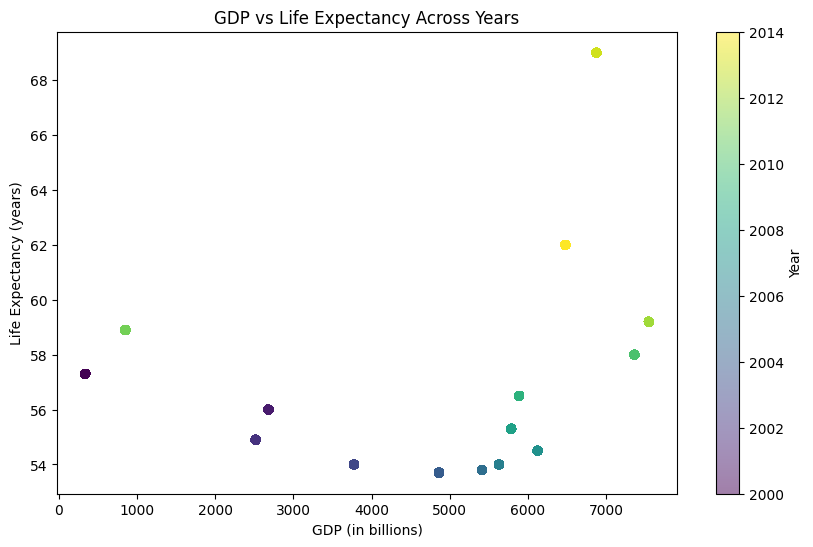

In [145]:
plt.figure(figsize=(10,6))
plt.scatter(final_merged['gdp'], final_merged['life_expectancy'], alpha=0.5, c=final_merged['year'], cmap='viridis')
plt.colorbar(label='Year')
plt.title('GDP vs Life Expectancy Across Years')
plt.xlabel('GDP (in billions)')
plt.ylabel('Life Expectancy (years)')
plt.show()





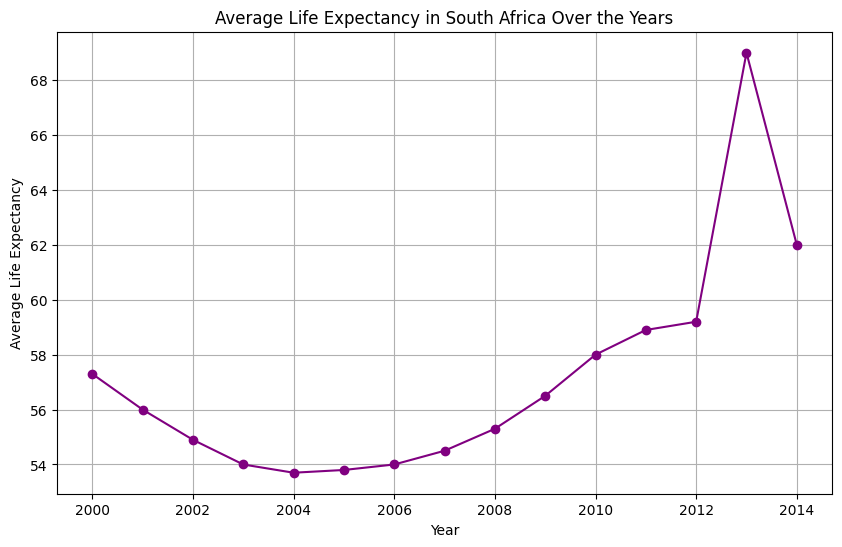

In [146]:
avg_life = final_merged.groupby('year')['life_expectancy'].mean()
plt.figure(figsize=(10,6))
avg_life.plot(kind='line', marker='o', color='purple')
plt.title('Average Life Expectancy in South Africa Over the Years')
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy')
plt.grid(True)
plt.show()



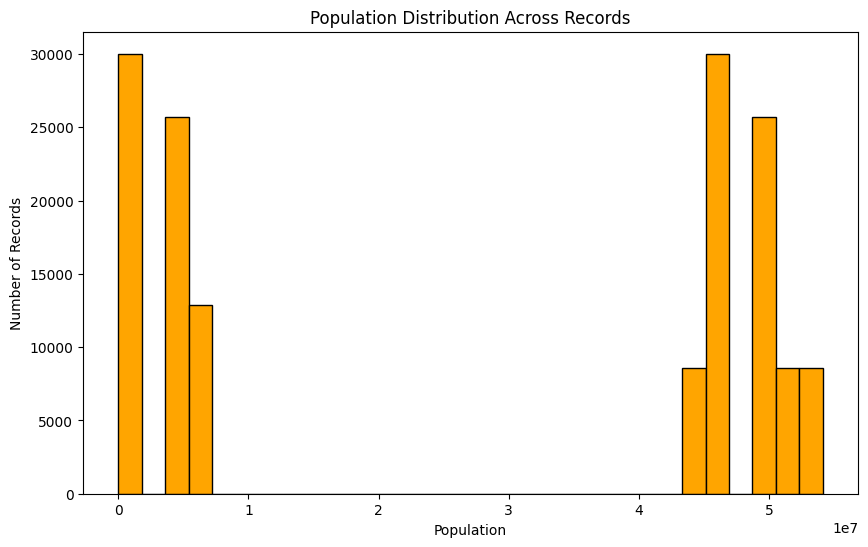

In [147]:
plt.figure(figsize=(10,6))
plt.hist(final_merged['population'], bins=30, color='orange', edgecolor='black')
plt.title('Population Distribution Across Records')
plt.xlabel('Population')
plt.ylabel('Number of Records')
plt.show()


/tmp/ipython-input-674816617.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_merged, x='facility_type', y='life_expectancy', palette='Set3')


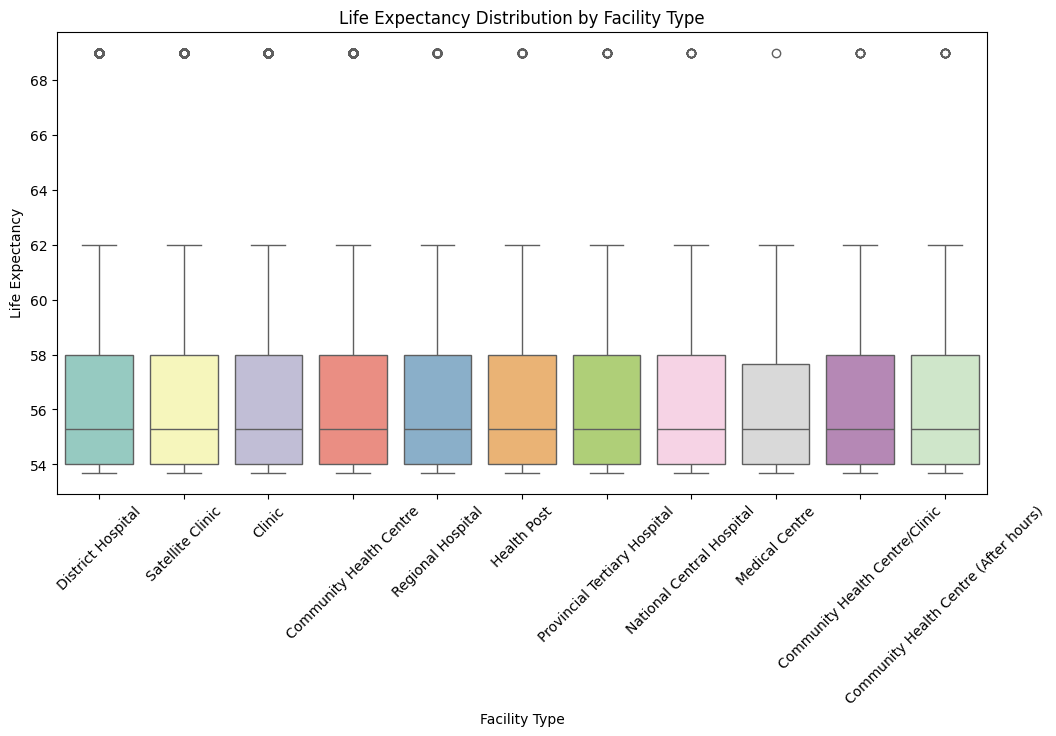

In [148]:
plt.figure(figsize=(12,6))
sns.boxplot(data=final_merged, x='facility_type', y='life_expectancy', palette='Set3')
plt.title('Life Expectancy Distribution by Facility Type')
plt.xlabel('Facility Type')
plt.ylabel('Life Expectancy')
plt.xticks(rotation=45)
plt.show()

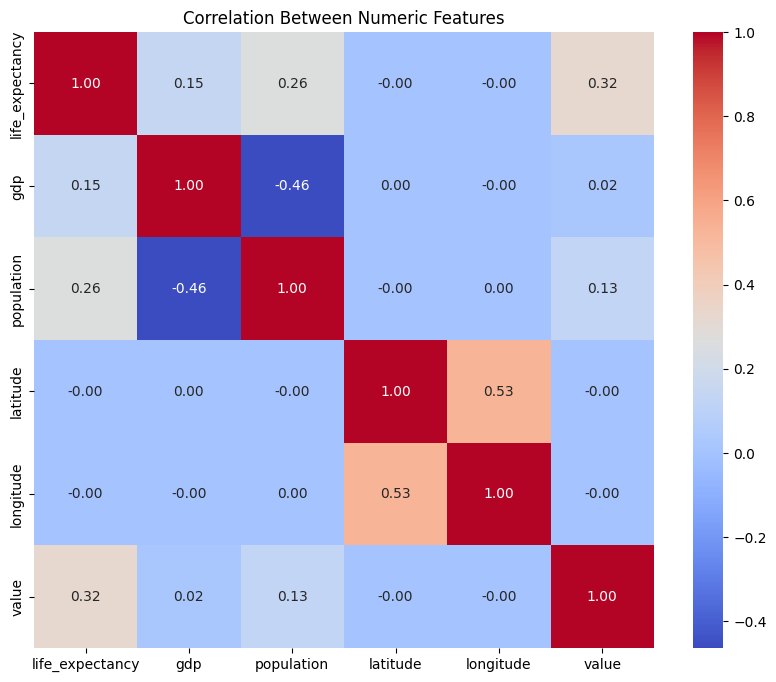

In [149]:
plt.figure(figsize=(10,8))
numeric_cols = ['life_expectancy', 'gdp', 'population', 'latitude', 'longitude', 'value']
corr = final_merged[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Numeric Features')
plt.show()


# Modeling

In [72]:
print(final_merged.columns)



Index(['country', 'year', 'life_expectancy', 'gdp', 'population', 'iso3',
       'indicator', 'code', 'value', 'Year', 'Value', 'facility_name',
       'facility_type', 'ownership', 'latitude', 'longitude'],
      dtype='object')


In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np



In [74]:
# Target variable
y = final_merged["life_expectancy"]

# Features
X = final_merged.drop(columns=["life_expectancy"])

# Identify categorical and numeric columns
categorical_cols = ["country", "iso3", "indicator", "code", "facility_name", "facility_type", "ownership"]
numeric_cols = ["year", "gdp", "population", "value", "Value", "latitude", "longitude"]

# Ensure numeric columns are numeric
for col in numeric_cols:
    X[col] = X[col].astype(str).str.replace(",", ".").astype(float)

# Preprocessor: OneHotEncode categoricals and keep numeric as-is
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)




In [75]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model.fit(X_train, y_train)




Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['country', 'iso3',
                                                   'indicator', 'code',
                                                   'facility_name',
                                                   'facility_type',
                                                   'ownership']),
                                                 ('num', 'passthrough',
                                                  ['year', 'gdp', 'population',
                                                   'value', 'Value', 'latitude',
                                                   'longitude'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [76]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Predictions for first 5 rows:", y_pred[:5])



Mean Squared Error: 3.4510640897666354e-24
Predictions for first 5 rows: [58.9 56.  69.  53.8 62. ]


In [77]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)


R² Score: 1.0


In [78]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)



RMSE: 1.8577039833532777e-12


In [79]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print("CV R² Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())



CV R² Scores: [ -0.69194405  -0.5518131  -20.94347826 -12.83333333  -3.64121037]
Mean CV R²: -7.732355822921585


In [81]:
final_merged[numeric_cols].describe().T[["min", "max", "mean", "std"]].sort_values("std", ascending=False)



,min,max,mean,std
population,4717.9900,5.414673e+07,2.763208e+07,2.265239e+07
gdp,337.2253,7.548164e+03,4.796011e+03,2.089187e+03
Value,0.6800,6.318400e+01,2.542103e+01,2.786860e+01
year,2000.0000,2.014000e+03,2.006371e+03,3.847726e+00
longitude,16.4818,3.281160e+01,2.742468e+01,3.591838e+00
latitude,-34.7828,-1.310090e+01,-2.865332e+01,3.296596e+00
